# Homework: Finite Scalar Quantization (FSQ)

Based on **"Finite Scalar Quantization: VQ-VAE Made Simple"** by Mentzer et al. (2023).

This notebook turns the paper into a **small-scale homework assignment**. The original paper studies FSQ as a drop-in replacement for VQ in large two-stage systems such as **MaskGIT** and **UViM**. For homework scale, you will build a simplified version on **MNIST**:

1. implement the FSQ quantizer,
2. train an FSQ autoencoder,
3. measure codebook usage,
4. train a tiny autoregressive prior on the discrete latent tokens,
5. sample new images by sampling tokens and decoding them.

The goal is not to reproduce the full paper. The goal is to understand the **core mechanism**:
- FSQ uses a **few latent dimensions**,
- each latent dimension is quantized to a **small fixed set of values**,
- the full codebook is **implicit** with size $\prod_i L_i$,
- a second model can be trained on the resulting discrete tokens.

The paper's main point is that FSQ keeps the two-stage discrete-latent pipeline, but removes many complications of VQ such as learned codebooks, commitment losses, and codebook maintenance tricks.

## What you must fill in

You should write the missing code in the cells marked **TODO**.

Required coding exercises:
1. `round_ste`
2. `FSQ.bound`
3. `FSQ.quantize`
4. `FSQ.codes_to_indices`
5. `FSQ.indices_to_codes`
6. `compute_codebook_usage`
7. `sample_autoregressive`

There are also short written questions. Leave your answers in markdown cells.

## Practical note

The paper trains on ImageNet/COCO-scale setups. That is too large for homework. This notebook uses:
- **MNIST**
- a small convolutional autoencoder
- a tiny causal transformer prior

That keeps the **paper's two-stage logic** while staying runnable on a laptop or Colab.

## Written questions

Answer these before you start coding.

**Q1.** Why does FSQ with per-channel levels $L = [L_1, \dots, L_d]$ have an implicit codebook of size $\prod_i L_i$?

> Each channel $i$ independently takes one of exactly $L_i$ discrete values. All valid quantized vectors are the Cartesian product of these per-channel value sets, so the total number of distinct codes is $L_1 \times L_2 \times \cdots \times L_d = \prod_i L_i$. No code vector is excluded, so the codebook is exactly this product set — it is "implicit" because it is never materialised as an explicit embedding table.

**Q2.** In one or two sentences, why does FSQ avoid the learned-codebook machinery of standard VQ?

> In FSQ the quantization grid is fully determined by the fixed level hyperparameters: each channel is bounded via a tanh-based nonlinearity and rounded to a pre-specified finite set, so there are no codebook embeddings to learn. Because the codebook is not parameterised, there is nothing to optimise with commitment losses, EMA updates, or codebook-reset heuristics — straight-through rounding suffices.

**Q3.** The paper recommends using $L_i \ge 5$ when possible. Why might very small numbers of levels hurt performance?

> With very few levels (e.g. $L_i = 2$ or $3$), each channel can represent only a handful of distinct values, severely limiting reconstruction quality because nearby inputs collapse to the same code. Additionally, with levels below 5 the quantisation error relative to the dynamic range of the bounded output is large, producing coarse representations that degrade both the autoencoder and any downstream model trained on the discrete tokens.

**Q4.** For the default levels in this notebook, `LEVELS = [8, 5, 5, 5]`, what is the codebook size?

> $8 \times 5 \times 5 \times 5 = \mathbf{1000}$.

In [1]:
# Core imports
import math
import random
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset

try:
    from torchvision import datasets, transforms
except ImportError as e:
    raise ImportError(
        "This notebook expects torchvision. On Colab it is usually preinstalled. "
        "Otherwise run: pip install torchvision"
    ) from e

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kwargs):
        return x


def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [2]:
@dataclass
class Config:
    # Paper-inspired FSQ levels: [8, 5, 5, 5] gives about 2^10 codes.
    LEVELS = [8, 5, 5, 5]

    # Data
    DATA_ROOT = "./data"
    TRAIN_SUBSET = 12000      # increase on GPU if you want
    TEST_SUBSET = 2000
    BATCH_SIZE = 128

    # Stage I: autoencoder
    AE_EPOCHS = 6 if torch.cuda.is_available() else 3
    AE_LR = 2e-3

    # Stage II: prior
    PRIOR_EPOCHS = 8 if torch.cuda.is_available() else 4
    PRIOR_LR = 3e-4
    D_MODEL = 128 if torch.cuda.is_available() else 96
    NHEAD = 4
    NLAYERS = 3

    # Sampling
    NUM_SAMPLES = 36
    TEMPERATURE = 1.0


cfg = Config()
CODEBOOK_SIZE = int(np.prod(cfg.LEVELS))
LATENT_DIM = len(cfg.LEVELS)

print("levels:", cfg.LEVELS)
print("latent_dim:", LATENT_DIM)
print("implicit codebook size:", CODEBOOK_SIZE)

levels: [8, 5, 5, 5]
latent_dim: 4
implicit codebook size: 1000


## Data

We use MNIST because it is small enough for homework. The paper's full experiments use much larger vision pipelines, but the key FSQ ideas do not depend on dataset scale.

In [3]:
transform = transforms.ToTensor()

train_dataset_full = datasets.MNIST(
    root=cfg.DATA_ROOT,
    train=True,
    download=True,
    transform=transform,
)
test_dataset_full = datasets.MNIST(
    root=cfg.DATA_ROOT,
    train=False,
    download=True,
    transform=transform,
)

train_indices = list(range(min(cfg.TRAIN_SUBSET, len(train_dataset_full))))
test_indices = list(range(min(cfg.TEST_SUBSET, len(test_dataset_full))))

train_dataset = Subset(train_dataset_full, train_indices)
test_dataset = Subset(test_dataset_full, test_indices)

train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("train subset size:", len(train_dataset))
print("test subset size:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.28MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 264kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]

train subset size: 12000
test subset size: 2000


In [4]:
def show_images(x, nrows=4, ncols=8, title=None, cmap="gray"):
    """
    x: tensor of shape (B, C, H, W)
    """
    x = x.detach().cpu()
    n = min(len(x), nrows * ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.6 * ncols, 1.6 * nrows))
    axes = np.array(axes).reshape(nrows, ncols)
    for ax in axes.flat:
        ax.axis("off")
    for i in range(n):
        img = x[i]
        if img.shape[0] == 1:
            axes.flat[i].imshow(img[0], cmap=cmap, vmin=0.0, vmax=1.0)
        else:
            axes.flat[i].imshow(img.permute(1, 2, 0).clamp(0, 1))
    if title is not None:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

/Users/danila.biktimirov/Library/Python/3.12/lib/python/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


batch shape: (128, 1, 28, 28)


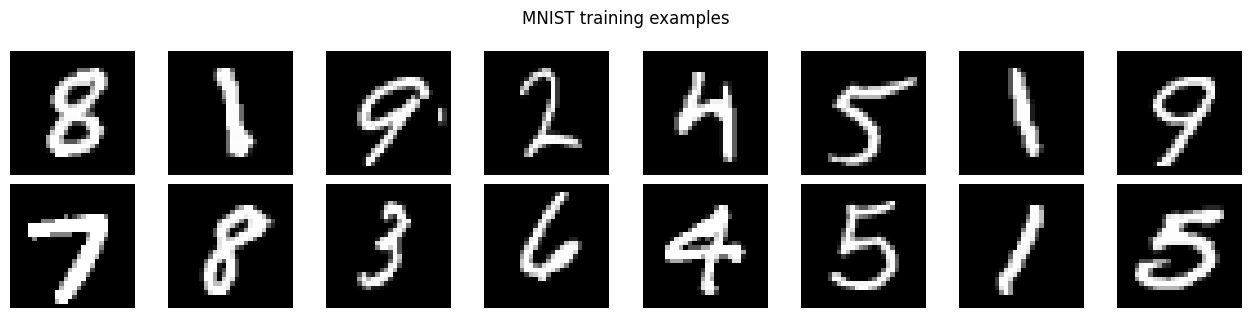

In [5]:
x_batch, y_batch = next(iter(train_loader))
print("batch shape:", tuple(x_batch.shape))
show_images(x_batch[:16], nrows=2, ncols=8, title="MNIST training examples")

## Part 1 — Implement straight-through rounding

The paper uses the straight-through estimator (STE) through the rounding operation. In modern PyTorch, the standard pattern is:

\[
\text{round\_ste}(x) = x + (\text{round}(x) - x).\text{detach()}
\]

Forward pass: behaves like `round(x)`.

Backward pass: behaves like the identity map.

### Exercise 1
Implement `round_ste`.

In [6]:
def round_ste(x: torch.Tensor) -> torch.Tensor:
    """
    Straight-through rounding.

    Forward:
        behaves like torch.round(x)
    Backward:
        gradient should be copied as if this were the identity
    """
    return x + (torch.round(x) - x).detach()

In [7]:
# Basic forward / backward test for round_ste
x = torch.tensor([-1.7, -0.2, 0.3, 2.8], requires_grad=True)
y = round_ste(x)

assert torch.allclose(y, torch.round(x)), "Forward pass should match torch.round"
y.sum().backward()
assert torch.allclose(x.grad, torch.ones_like(x)), "STE gradient should act like identity"
print("round_ste passed the basic test.")

round_ste passed the basic test.


## Part 2 — Implement FSQ

We will follow the paper's Appendix A.1 in spirit, but in PyTorch and with a simplified interface.

The FSQ bottleneck works as follows:
1. take a latent vector $z \in \mathbb{R}^d$,
2. **bound** each channel into the finite range supported by its level count,
3. **round** with STE,
4. normalize the quantized code back into a stable numeric range for the decoder,
5. optionally map each quantized code vector to a single integer token.

### Shape convention

In the quantizer below, all public methods use tensors of shape:

\[
(..., d)
\]

where the last dimension stores the FSQ channels.

### Exercise 2
Implement the missing methods in `FSQ`.

In [8]:
class FSQ(nn.Module):
    """
    Finite Scalar Quantization.

    Levels example:
        [8, 5, 5, 5]

    Then:
        d = 4
        codebook size = 8 * 5 * 5 * 5 = 1000

    Public methods expect shape (..., d).
    """

    def __init__(self, levels):
        super().__init__()
        self.levels_list = list(levels)
        self.dim = len(self.levels_list)
        self.codebook_size = int(np.prod(self.levels_list))

        levels_t = torch.tensor(self.levels_list, dtype=torch.long)
        basis = [1]
        for l in self.levels_list[:-1]:
            basis.append(basis[-1] * l)

        self.register_buffer("levels", levels_t)
        self.register_buffer("basis", torch.tensor(basis, dtype=torch.long))

    def bound(self, z: torch.Tensor) -> torch.Tensor:
        """
        Bound z so that after rounding each channel lands in the correct finite set.

        For odd levels L_i the tanh output is centred at 0, covering {-(L-1)/2, ..., (L-1)/2}.
        For even levels a 0.5-offset shifts the grid so that rounding still yields L distinct values.
        """
        eps = 1e-3
        levels = self.levels.to(dtype=z.dtype, device=z.device)
        half_l = (levels - 1) * (1 - eps) / 2
        offset = torch.where(
            levels % 2 == 0,
            torch.full_like(half_l, 0.5),
            torch.zeros_like(half_l),
        )
        shift = torch.atanh(offset / half_l)
        return torch.tanh(z + shift) * half_l - offset

    def quantize(self, z: torch.Tensor) -> torch.Tensor:
        """
        Quantize z and return normalized codes with the same shape.

        1) bound z into the finite range for each channel,
        2) round with STE,
        3) normalize by half_width so the output lives in [-1, 1].
        """
        bounded = self.bound(z)
        quantized = round_ste(bounded)
        half_width = self._half_width(dtype=z.dtype).to(z.device)
        return quantized / half_width

    def _half_width(self, dtype=torch.float32):
        return torch.div(self.levels, 2, rounding_mode="floor").to(dtype=dtype)

    def _scale_and_shift(self, zhat_normalized: torch.Tensor) -> torch.Tensor:
        half_width = self._half_width(dtype=zhat_normalized.dtype).to(zhat_normalized.device)
        return zhat_normalized * half_width + half_width

    def _scale_and_shift_inverse(self, zhat: torch.Tensor) -> torch.Tensor:
        half_width = self._half_width(dtype=zhat.dtype).to(zhat.device)
        return (zhat - half_width) / half_width

    def codes_to_indices(self, zhat_normalized: torch.Tensor) -> torch.Tensor:
        """
        Convert quantized FSQ codes (..., d) into integer token indices (...).

        Undo the normalisation to get non-centred integer coordinates [0, L_i - 1],
        then perform mixed-radix encoding with self.basis.
        """
        zhat = self._scale_and_shift(zhat_normalized)     
        zhat_int = torch.round(zhat).long()                  
        basis = self.basis.to(device=zhat_int.device)
        return (zhat_int * basis).sum(dim=-1)          

    def indices_to_codes(self, indices: torch.Tensor) -> torch.Tensor:
        """
        Inverse of codes_to_indices.

        Input:
            indices with shape (...)

        Output:
            normalized FSQ codes with shape (..., d)
        """
        levels = self.levels.to(device=indices.device)
        basis = self.basis.to(device=indices.device)
        indices_expanded = indices.unsqueeze(-1)             
        zhat = (indices_expanded // basis) % levels           
        return self._scale_and_shift_inverse(zhat.float())

In [9]:
# Toy round-trip test with a small codebook
toy_fsq = FSQ([3, 5])

all_idx = torch.arange(toy_fsq.codebook_size)
codes = toy_fsq.indices_to_codes(all_idx)
roundtrip = toy_fsq.codes_to_indices(codes)

assert torch.equal(all_idx, roundtrip.cpu()), "codes_to_indices and indices_to_codes should invert each other"

# Test number of distinct quantization values per dimension
z = torch.linspace(-10, 10, 1000)[:, None].repeat(1, 2)
q = toy_fsq.quantize(z)

num_unique_dim0 = torch.unique(q[:, 0]).numel()
num_unique_dim1 = torch.unique(q[:, 1]).numel()

assert num_unique_dim0 == 3, f"Expected 3 levels in dim 0, got {num_unique_dim0}"
assert num_unique_dim1 == 5, f"Expected 5 levels in dim 1, got {num_unique_dim1}"

print("FSQ basic tests passed.")

FSQ basic tests passed.


## Part 3 — Build a small FSQ autoencoder

The paper's Stage I model is a discrete autoencoder. Ours is much smaller than the paper's model, but has the same structure:

- encoder $\rightarrow$ latent tensor
- FSQ bottleneck
- decoder $\rightarrow$ reconstruction

Each spatial location gets a **small FSQ vector** and also a **single discrete token index**.

In [10]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(inplace=True),
            nn.Conv2d(64, latent_dim, kernel_size=1),
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 64, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),           # 14 -> 28
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, zq):
        return self.net(zq)


class FSQAutoencoder(nn.Module):
    def __init__(self, levels):
        super().__init__()
        latent_dim = len(levels)
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.quantizer = FSQ(levels)

    def encode_to_codes(self, x):
        ze = self.encoder(x)                              # (B, d, 7, 7)
        ze_last = ze.permute(0, 2, 3, 1).contiguous()   # (B, 7, 7, d)
        zq_last = self.quantizer.quantize(ze_last)      # (B, 7, 7, d)
        idx = self.quantizer.codes_to_indices(zq_last)  # (B, 7, 7)
        return ze_last, zq_last, idx

    def decode_from_codes(self, zq_last):
        zq = zq_last.permute(0, 3, 1, 2).contiguous()
        return self.decoder(zq)

    def decode_from_indices(self, idx):
        zq_last = self.quantizer.indices_to_codes(idx)
        return self.decode_from_codes(zq_last)

    def forward(self, x):
        ze_last, zq_last, idx = self.encode_to_codes(x)
        x_hat = self.decode_from_codes(zq_last)
        return {
            "x_hat": x_hat,
            "indices": idx,
            "ze_last": ze_last,
            "zq_last": zq_last,
        }


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


ae = FSQAutoencoder(cfg.LEVELS).to(device)
print(ae)
print("trainable params:", count_parameters(ae))

FSQAutoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): Conv2d(64, 4, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): ConvTranspose2d(4, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): Sigmoid()
    )
  )
  (quantizer): FSQ()
)
trainable params: 70885


In [11]:
with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.to(device)[:4]
    out = ae(x)
    print("input:", tuple(x.shape))
    print("reconstruction:", tuple(out["x_hat"].shape))
    print("latent codes:", tuple(out["zq_last"].shape))
    print("token indices:", tuple(out["indices"].shape))

input: (4, 1, 28, 28)
reconstruction: (4, 1, 28, 28)
latent codes: (4, 7, 7, 4)
token indices: (4, 7, 7)


## Part 4 — Train Stage I (autoencoder)

The paper's Stage I is a reconstruction model. We do the same here, with simple BCE reconstruction loss.

In [12]:
def reconstruction_loss(x_hat, x):
    return F.binary_cross_entropy(x_hat, x)


def run_ae_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_items = 0

    iterator = tqdm(loader, leave=False)
    for x, _ in iterator:
        x = x.to(device, non_blocking=True)

        out = model(x)
        loss = reconstruction_loss(out["x_hat"], x)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_items += x.size(0)

    return total_loss / max(1, total_items)


def train_autoencoder(model, train_loader, test_loader, epochs, lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "test_loss": []}

    for epoch in range(1, epochs + 1):
        train_loss = run_ae_epoch(model, train_loader, optimizer)
        test_loss = run_ae_epoch(model, test_loader, optimizer=None)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)

        print(f"[AE] epoch {epoch:02d} | train {train_loss:.4f} | test {test_loss:.4f}")

    return history

In [13]:
ae = FSQAutoencoder(cfg.LEVELS).to(device)
ae_history = train_autoencoder(
    ae,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=cfg.AE_EPOCHS,
    lr=cfg.AE_LR,
)

  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

[AE] epoch 01 | train 0.2545 | test 0.1129


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

[AE] epoch 02 | train 0.0977 | test 0.0896


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

[AE] epoch 03 | train 0.0878 | test 0.0845


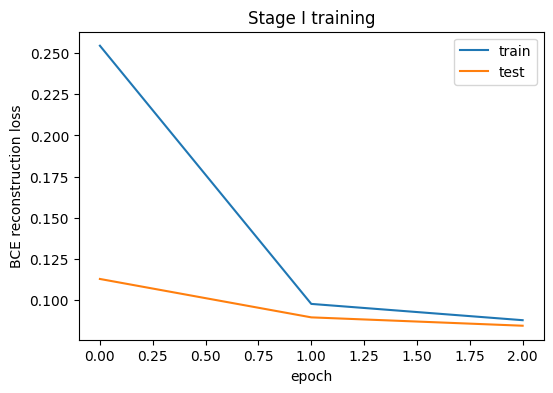

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(ae_history["train_loss"], label="train")
plt.plot(ae_history["test_loss"], label="test")
plt.xlabel("epoch")
plt.ylabel("BCE reconstruction loss")
plt.title("Stage I training")
plt.legend()
plt.show()

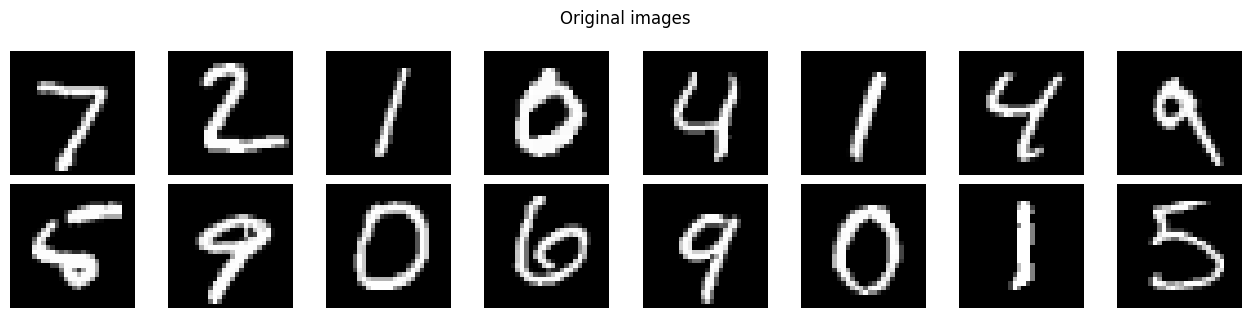

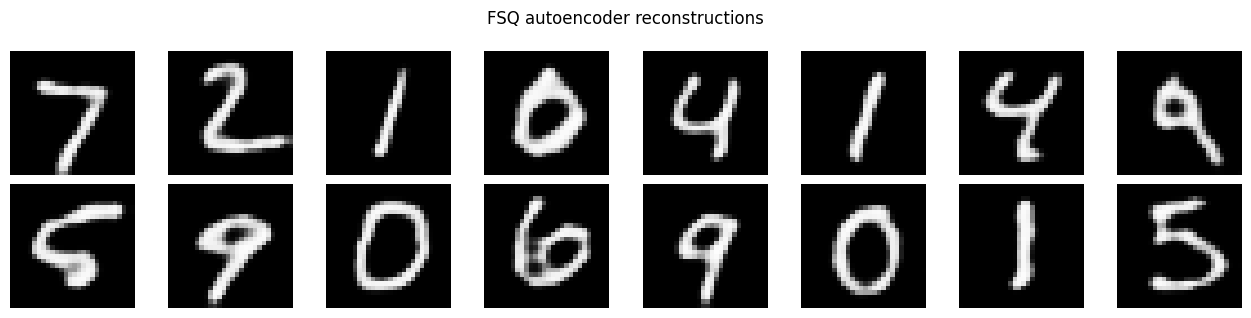

In [15]:
ae.eval()
with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x.to(device)[:16]
    out = ae(x)
    x_hat = out["x_hat"]

show_images(x, nrows=2, ncols=8, title="Original images")
show_images(x_hat, nrows=2, ncols=8, title="FSQ autoencoder reconstructions")

## Part 5 — Measure codebook usage

A major theme of the paper is that FSQ tends to use the codebook well, without auxiliary VQ tricks.

Here we compute the fraction of token IDs that appear at least once on a dataset split.

### Exercise 3
Implement `compute_codebook_usage`.

In [16]:
@torch.no_grad()
def compute_codebook_usage(model: FSQAutoencoder, loader: DataLoader):
    """
    Returns
    -------
    usage_fraction : float
        fraction of codebook entries used at least once
    counts : torch.Tensor
        tensor of shape (codebook_size,) with token counts
    """
    model.eval()
    counts = torch.zeros(model.quantizer.codebook_size, dtype=torch.long)

    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        out = model(x)
        idx = out["indices"].reshape(-1).cpu()
        counts += torch.bincount(idx, minlength=model.quantizer.codebook_size)

    usage_fraction = (counts > 0).float().mean().item()
    return usage_fraction, counts

used codes: 25/1000
usage fraction: 2.50%
top 10 token counts: [45435, 6783, 6425, 4765, 3393, 2936, 2830, 2523, 2407, 2208]


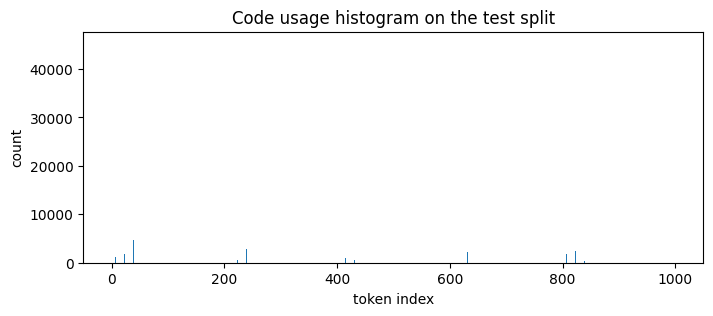

In [17]:
usage_fraction, counts = compute_codebook_usage(ae, test_loader)
used = int((counts > 0).sum().item())

print(f"used codes: {used}/{len(counts)}")
print(f"usage fraction: {usage_fraction:.2%}")
print(f"top 10 token counts: {torch.topk(counts, k=10).values.tolist()}")

plt.figure(figsize=(8, 3))
plt.bar(np.arange(len(counts)), counts.numpy())
plt.xlabel("token index")
plt.ylabel("count")
plt.title("Code usage histogram on the test split")
plt.show()

## Part 6 — Convert images into token sequences

To train a Stage II model, we first encode each image into its discrete FSQ token grid and then flatten that grid into a sequence.

This mirrors the paper's idea that once FSQ codes are turned into integers, the representation can be modeled by a sequence model.

In [18]:
@torch.no_grad()
def encode_dataset_to_token_sequences(model: FSQAutoencoder, loader: DataLoader):
    model.eval()
    all_tokens = []

    for x, _ in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        out = model(x)
        idx = out["indices"]                  # (B, H, W)
        seq = idx.view(idx.size(0), -1)       # (B, S)
        all_tokens.append(seq.cpu())

    return torch.cat(all_tokens, dim=0)


train_token_sequences = encode_dataset_to_token_sequences(ae, train_loader)
test_token_sequences = encode_dataset_to_token_sequences(ae, test_loader)

latent_h = latent_w = int(math.sqrt(train_token_sequences.shape[1]))
seq_len = train_token_sequences.shape[1]

print("token sequence shape:", tuple(train_token_sequences.shape))
print("sequence length:", seq_len)
print("latent grid:", (latent_h, latent_w))

  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

token sequence shape: (12000, 49)
sequence length: 49
latent grid: (7, 7)


In [19]:
token_train_loader = DataLoader(
    TensorDataset(train_token_sequences),
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
token_test_loader = DataLoader(
    TensorDataset(test_token_sequences),
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

## Part 7 — A tiny causal transformer prior

The paper's Stage II uses a transformer over discrete latent representations. We use a much smaller causal transformer that predicts the next token in the flattened latent sequence.

The input/output contract is:

- target tokens: shape `(B, S)`
- model outputs logits of shape `(B, S, vocab_size)`

At training time we use teacher forcing.

In [20]:
def causal_mask(size: int, device):
    """
    Upper-triangular mask with -inf above the diagonal.
    """
    mask = torch.full((size, size), float("-inf"), device=device)
    mask = torch.triu(mask, diagonal=1)
    return mask


class TinyCausalTransformer(nn.Module):
    def __init__(self, vocab_size, max_seq_len, d_model=128, nhead=4, num_layers=3):
        super().__init__()
        self.vocab_size = vocab_size
        self.bos_token = vocab_size

        self.token_emb = nn.Embedding(vocab_size + 1, d_model)  # +1 for BOS
        self.pos_emb = nn.Parameter(torch.randn(1, max_seq_len + 1, d_model) * 0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=4 * d_model,
            dropout=0.1,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def teacher_forcing_inputs(self, tokens):
        """
        tokens: (B, S)
        returns inputs of shape (B, S) = [BOS, x_0, x_1, ..., x_{S-2}]
        """
        B, S = tokens.shape
        bos = torch.full((B, 1), self.bos_token, dtype=torch.long, device=tokens.device)
        return torch.cat([bos, tokens[:, :-1]], dim=1)

    def forward(self, tokens):
        inp = self.teacher_forcing_inputs(tokens)
        B, S = inp.shape
        x = self.token_emb(inp) + self.pos_emb[:, :S, :]
        mask = causal_mask(S, inp.device)
        h = self.transformer(x, mask=mask)
        return self.head(self.norm(h))

    def next_logits(self, prefix):
        """
        prefix: (B, T) where T may be 0
        returns logits for the next token, shape (B, vocab_size)
        """
        B, T = prefix.shape
        bos = torch.full((B, 1), self.bos_token, dtype=torch.long, device=prefix.device)
        inp = torch.cat([bos, prefix], dim=1)   # length T+1
        S = inp.shape[1]
        x = self.token_emb(inp) + self.pos_emb[:, :S, :]
        mask = causal_mask(S, inp.device)
        h = self.transformer(x, mask=mask)
        return self.head(self.norm(h[:, -1]))


prior = TinyCausalTransformer(
    vocab_size=CODEBOOK_SIZE,
    max_seq_len=seq_len,
    d_model=cfg.D_MODEL,
    nhead=cfg.NHEAD,
    num_layers=cfg.NLAYERS,
).to(device)

print(prior)
print("prior params:", count_parameters(prior))

TinyCausalTransformer(
  (token_emb): Embedding(1001, 96)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=384, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=384, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=96, out_features=1000, bias=True)
)
prior params: 533608


/Users/danila.biktimirov/Library/Python/3.12/lib/python/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [21]:
def run_prior_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_items = 0

    for (tokens,) in tqdm(loader, leave=False):
        tokens = tokens.to(device, non_blocking=True)

        logits = model(tokens)  # (B, S, V)
        loss = F.cross_entropy(
            logits.reshape(-1, model.vocab_size),
            tokens.reshape(-1),
        )

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * tokens.size(0)
        total_items += tokens.size(0)

    return total_loss / max(1, total_items)


def train_prior(model, train_loader, test_loader, epochs, lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "test_loss": []}

    for epoch in range(1, epochs + 1):
        train_loss = run_prior_epoch(model, train_loader, optimizer)
        test_loss = run_prior_epoch(model, test_loader, optimizer=None)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)

        print(f"[PRIOR] epoch {epoch:02d} | train {train_loss:.4f} | test {test_loss:.4f}")

    return history

### Exercise 4 — Autoregressive sampling

Implement sampling from the prior.

You should:
1. start from an empty prefix,
2. repeatedly request `prior.next_logits(prefix)`,
3. divide by temperature,
4. sample one token per example,
5. append sampled tokens until the sequence is complete.

In [22]:
@torch.no_grad()
def sample_autoregressive(prior, num_samples, seq_len, temperature=1.0, device=device):
    """
    Returns:
        sampled token tensor of shape (num_samples, seq_len)
    """
    prior.eval()
    generated = torch.empty(num_samples, 0, dtype=torch.long, device=device)

    for _ in range(seq_len):
        logits = prior.next_logits(generated)        
        logits = logits / temperature
        probs = torch.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)   
        generated = torch.cat([generated, next_token], dim=1)

    return generated

In [23]:
prior = TinyCausalTransformer(
    vocab_size=CODEBOOK_SIZE,
    max_seq_len=seq_len,
    d_model=cfg.D_MODEL,
    nhead=cfg.NHEAD,
    num_layers=cfg.NLAYERS,
).to(device)

prior_history = train_prior(
    prior,
    train_loader=token_train_loader,
    test_loader=token_test_loader,
    epochs=cfg.PRIOR_EPOCHS,
    lr=cfg.PRIOR_LR,
)

  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

[PRIOR] epoch 01 | train 3.6201 | test 2.2719


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

...

  0%|          | 0/16 [00:00<?, ?it/s]

[PRIOR] epoch 03 | train 1.7538 | test 1.6577


  0%|          | 0/94 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

[PRIOR] epoch 04 | train 1.6571 | test 1.5917


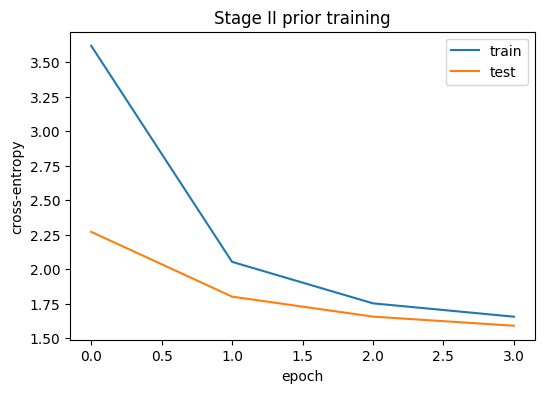

In [24]:
plt.figure(figsize=(6, 4))
plt.plot(prior_history["train_loss"], label="train")
plt.plot(prior_history["test_loss"], label="test")
plt.xlabel("epoch")
plt.ylabel("cross-entropy")
plt.title("Stage II prior training")
plt.legend()
plt.show()

In [25]:
sampled_tokens = sample_autoregressive(
    prior,
    num_samples=cfg.NUM_SAMPLES,
    seq_len=seq_len,
    temperature=cfg.TEMPERATURE,
    device=device,
)

print("sampled token shape:", tuple(sampled_tokens.shape))

sampled token shape: (36, 49)


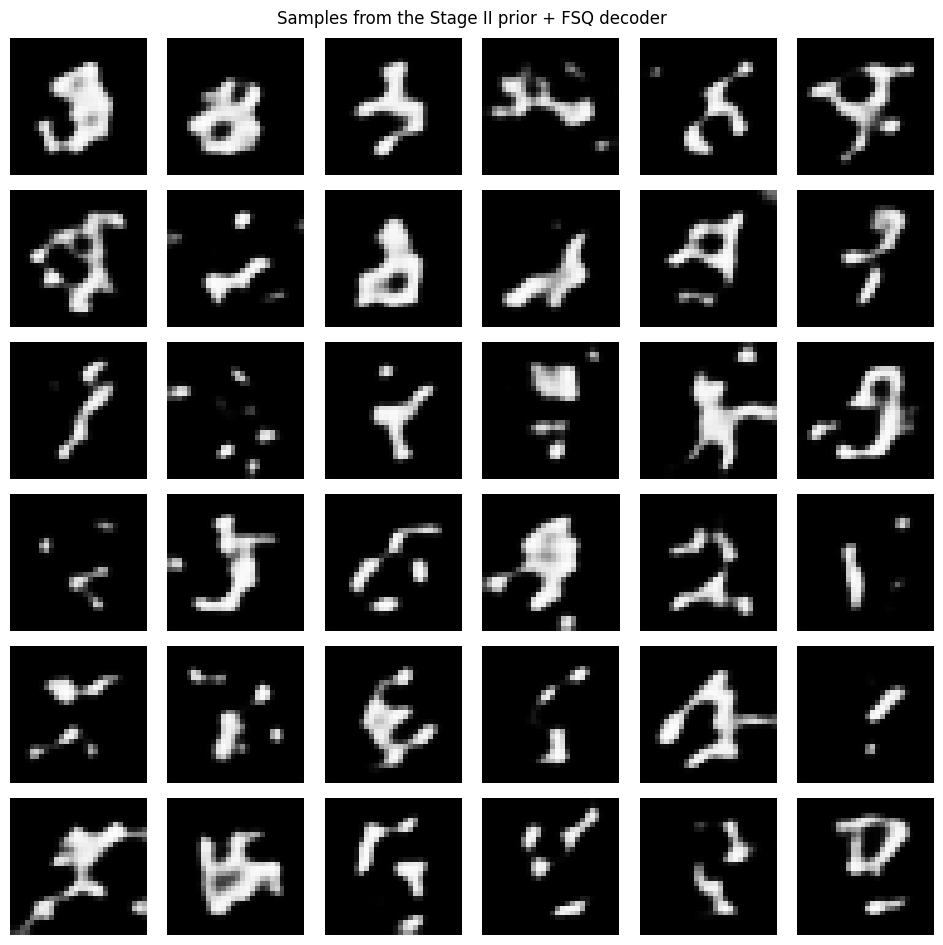

In [26]:
with torch.no_grad():
    sampled_grid = sampled_tokens.view(-1, latent_h, latent_w)
    sampled_images = ae.decode_from_indices(sampled_grid.to(device))

show_images(sampled_images, nrows=6, ncols=6, title="Samples from the Stage II prior + FSQ decoder")

## Reflection

Answer these after training and sampling.

**R1.** Did the autoencoder reconstructions preserve the main digit structure? Where do they fail?

> Write your answer here.

**R2.** What codebook usage did you get? Was it high or low relative to the codebook size?

> Write your answer here.

**R3.** Compare the sampled images to reconstructed test images. Which stage seems to be the bottleneck: the autoencoder or the prior?

> Write your answer here.

**R4.** In the paper, FSQ is used as a drop-in replacement for VQ in large models. Based on this homework, why is it plausible that a simple fixed quantizer can still work well?

> Write your answer here.

## Optional extensions

1. Try different level configurations with similar codebook sizes, for example:
   - `[10, 10, 10]`
   - `[8, 5, 5, 5]`
   - `[7, 5, 5, 5, 5]`

2. Compare usage and sample quality for larger or smaller codebooks.

3. Replace MNIST with FashionMNIST.

4. Replace the causal prior with a masked-token model, closer in spirit to MaskGIT.

5. Add a small written comparison between FSQ and standard VQ:
   - learned vs fixed codebook,
   - auxiliary losses,
   - codebook collapse,
   - parameter count.

## Paper pointers

If you need hints while solving the exercises, these are the most relevant places in the paper:

- **Section 3.1**: FSQ definition and the implicit codebook.
- **Section 3.2**: hyperparameters and the recommendation to use sufficiently many levels.
- **Section 4.1**: the two-stage setup (Stage I autoencoder, Stage II model over discrete codes).
- **Appendix A.1**: reference FSQ implementation.

Do not copy Appendix A.1 directly. Translate the ideas into the missing PyTorch code yourself.